### PROJECT OVERVIEW

This project is a Python-based data analysis dashboard designed to explore applicant data from a real-world admission scennario(UC Berkeley 1973). The goal is to demonstrate mastery of Exploratory Data Analysis(EDA) and Data Stiorytelling by uncovering the "Simpson's Paradox" in admissions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("https://waf.cs.illinois.edu/discovery/berkeley.csv")

In [3]:
df.head(10)

,Year,Major,Sex,Admission
0,1973,C,F,Rejected
1,1973,B,M,Accepted
2,1973,Other,F,Accepted
3,1973,Other,M,Accepted
4,1973,Other,M,Rejected
5,1973,Other,M,Rejected
6,1973,F,F,Accepted
7,1973,Other,M,Accepted
8,1973,Other,M,Rejected
9,1973,A,M,Accepted


In [4]:
df.shape

(12763, 4)

### DATA CLEANING

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12763 entries, 0 to 12762
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Year       12763 non-null  int64 
 1   Major      12763 non-null  object
 2   Sex        12763 non-null  object
 3   Admission  12763 non-null  object
dtypes: int64(1), object(3)
memory usage: 399.0+ KB


In [6]:
df.isna().sum()

Year         0
Major        0
Sex          0
Admission    0
dtype: int64

In [7]:
duplicate_count = df.duplicated().sum()

In [8]:
duplicate_count

np.int64(12735)

In [9]:
unique_combination = len(df) - duplicate_count
unique_combination

np.int64(28)

The high duplicate count of 12,735 outof the entire 12,763 rows reveals that the applicant pool is categorized into 28 distinct profiles. This sugests that admission outocmes are highly standardizd based on  the Major and the Gender,rather than he individual's scores(this is as regards to this dataset)

The 28 Unique profile can be obtained from all the possible combinations in all columns of the dataset
For the Yaer column,All are the same-1973(1 Distinct profile)
For the Major column, we have- A,B,C,D,E,F and Other(7 Distinct profiles)
For the Sex column, we have Male an Female(2 Distinct profiles)
For the Admsiion column, we have Accepted and Rejected(2 Distinct Profiles)

So,if you multiply all possible combination(1 * 7 * 2 * 2) ,you will have 28 distinct profiles

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,12763.0,1973.0,0.0,1973.0,1973.0,1973.0,1973.0,1973.0


In [11]:
df['Major'].unique()

array(['C', 'B', 'Other', 'F', 'A', 'D', 'E'], dtype=object)

In [12]:
df.columns = df.columns.str.lower()

In [13]:
df.sample(4)

,year,major,sex,admission
11995,1973,Other,M,Accepted
1753,1973,Other,F,Rejected
5816,1973,Other,M,Rejected
4916,1973,Other,M,Rejected


##### ACCEPTANCE RATE, GENDER RATIO AND TOP 5 PROBRAMS BY DEMAND COMPUTATION

In [14]:
#ACCEPTANCE RATE

In [15]:
accepted_count = len(df[df['admission'] == 'Accepted'])
accepted_count

5232

In [16]:
overall_acceptance_rate = (accepted_count / len(df)) * 100
overall_acceptance_rate

40.99349682676487

In [17]:
df['admission'].value_counts()

admission
Rejected    7531
Accepted    5232
Name: count, dtype: int64

In [18]:
#GENDER RATIO

In [19]:
gender_count = df['sex'].value_counts()

In [20]:
gender_count

sex
M    8442
F    4321
Name: count, dtype: int64

In [21]:
gender_ratio = (gender_count / len(df)) * 100
gender_ratio

sex
M    66.144323
F    33.855677
Name: count, dtype: float64

In [22]:
df['major'].unique()

array(['C', 'B', 'Other', 'F', 'A', 'D', 'E'], dtype=object)

In this dataset A,B,C,D,E,F,and Other may look like grades,but they are not,rather,they are Departmental Codes(Anonymous Program Names),and the university choose to anonymize them inorder to protect the departments' identities while allowing analysts to study the Program Demand.

For example
Major A: Department A (e.g., Engineering)
Major B: Department B (e.g., Chemistry) and so on.

In [23]:
#The Top 5 major progrmas
top_5_majors = df['major'].value_counts().head(5)
print(top_5_majors)

major
Other    7924
A        1246
C         918
D         792
F         714
Name: count, dtype: int64


- "Other" is the dominant category (7,924 applicants): This represents over 62% of all applicants. In a real-world scenario, this usually means the university has many smaller departments that aren't large enough to be listed individually (A-F).
- 
- Major A (1,246 applicants): This is the most popular single department.
- 
- Major C (918), D (792), and F (714): These are the next most competitive in terms of sheer volume.

Now, the Big Question is- Are the 66% of men applying to 'Major A' or the 'Other' Category?
Ar the 33% of women applying to 'Major F'?

- The impact of this is that If women are applying to the most crowded or difficutl majors, then their cceptance rate will be lower,even if the university isn't biased. 

### DATA VISUALIZATION

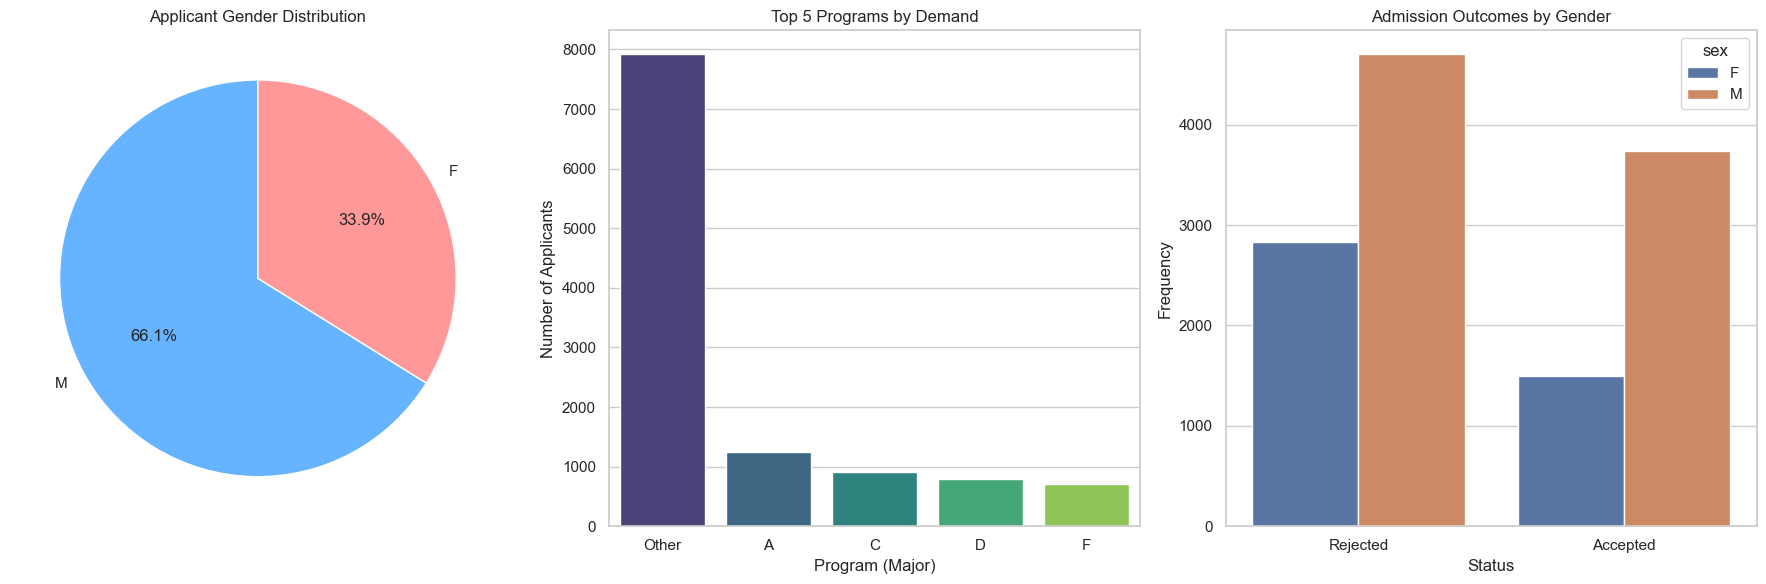

In [24]:
# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

#Pie Chart: Gender Distribution (Using the 66% vs 33% result)
plt.subplot(1, 3, 1)
plt.pie(gender_count, labels=gender_count.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Applicant Gender Distribution')

# Bar Chart: Top 5 Programs by Demand (Using th Other, A, C, D, F result)
plt.subplot(1, 3, 2)
sns.barplot(x=top_5_majors.index, y=top_5_majors.values, palette="viridis")
plt.title('Top 5 Programs by Demand')
plt.xlabel('Program (Major)')
plt.ylabel('Number of Applicants')

#Stacked Bar (Histogram equivalent): Admission Outcomes by Gender
plt.subplot(1, 3, 3)
# This shows how many Men/Women were Accepted vs Rejected
sns.countplot(data=df, x='admission', hue='sex')
plt.title('Admission Outcomes by Gender')
plt.xlabel('Status')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Chart 1 (Pie Chart): Confirms the 2:1 Male-to-Female ratio (66.1% vs 33.9%). This is the most important context for everything else.
Chart 2 (Bar Chart): Shows that "Other" is overwhelmingly the largest category, followed by Major A. This suggests that while Major A is the most popular specific department, most students are applying to a variety of other smaller programs.
Chart 3 (Stacked Bar Chart): At first glance, the "Accepted" column shows way more orange (Men). However, the "Rejected" column also shows way more orange. This proves the higher volume of male applicants is the primary driver of the chart's appearance, not necessarily a bias in the selection process.

In [25]:
#ACCEPTANCE RATE PER MAJOR

In [26]:
# Calculate % Acceptance for each Major
major_acc = df.groupby('major')['admission'].apply(lambda x: (x == 'Accepted').sum() / len(x) * 100).sort_values(ascending=False)
major_acc

major
A        73.354735
B        63.247863
Other    39.929329
C        34.967320
D        33.964646
E        25.171233
F         6.582633
Name: admission, dtype: float64

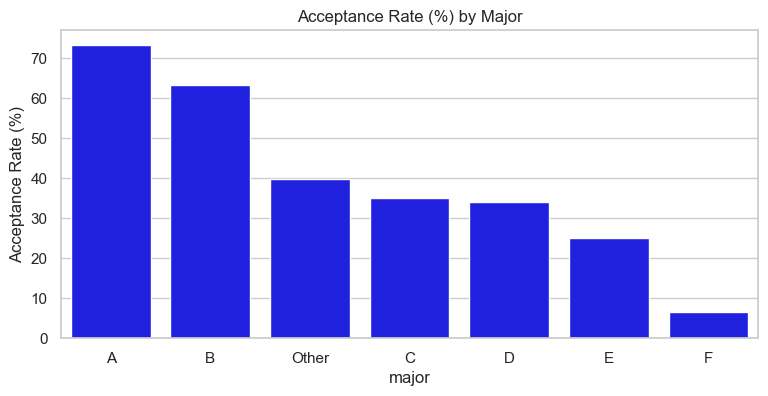

In [27]:
plt.figure(figsize=(9,4))
sns.barplot(x=major_acc.index, y=major_acc.values, color='blue')
plt.title('Acceptance Rate (%) by Major')
plt.ylabel('Acceptance Rate (%)')
plt.show()

In [28]:
df['major'].value_counts()

major
Other    7924
A        1246
C         918
D         792
F         714
B         585
E         584
Name: count, dtype: int64

In [29]:
# This shows the "Applicant Volume" per Major, split by Gender
major_gender_counts = pd.crosstab(df['major'], df['sex'])
print(major_gender_counts)

sex       F     M
major            
A       108  1138
B        25   560
C       593   325
D       375   417
E       393   191
F       341   373
Other  2486  5438


##### The Ambition Insight(Men vs Women)
- As for the Men (M): They flocked to Major A (1,138 men) and Major B (560 men). As we found earlier, these are the "easiest" majors with 73% and 63% acceptance rates.
As for the Women (F): They were much more ambitious! Look at Major C (593 women vs 325 men) and Major E (393 women vs 191 men). These majors are much "tougher," with much lowerr acceptance rates of only 34% and 25%.
In Conclusion: The men applied in massive numbers to the programs where it is easiest to get in, while the women applied in higher ratios to the programs that are much more competitive.

A higher percentage of the female pool ended up in the 'Rejected' pile, because more women were ready to fight for the few spots in the hard majors or programs.

This tells that the university institution isn't neccessarily rejecting women because they are women, but its rejecting them because they are applying to the most crowded and difficult programs in the university.

### DATA EXPORTATION AND AI-POWERED FEATURE INTEGRATION

In [30]:
# Create the Summary Table
summary_report = pd.DataFrame({
    'Metric': ['Total Applicants', 'Overall Acceptance Rate (%)', 'Male Applicants (%)', 'Female Applicants (%)'],
    'Value': [len(df), round(overall_acceptance_rate, 2), 66.14, 33.86]
})
# Export summary table
summary_report.to_csv("admission_summary_report.csv", index=False)
summary_report.to_html("admission_summary_report.html", index=False)
print("\nSummary reports successfully exported as CSV and HTML!")


Summary reports successfully exported as CSV and HTML!


In [34]:
#AI-POWERED FEATURE (Automatic Insight Generator)
def ai_insight_generator(df):
    summary = f" The Admission Data Explorer has processed {len(df)} records. "
    summary += f" The overall acceptance rate stands at {overall_acceptance_rate:.2f}%. "
    summary += f" The most in-demand program is Major '\n{top_5_majors}'. "
    summary += f" \nSTRATEGIC INSIGHT: The high duplicate count confirms that the 12,763 applications boil down to 28 distinct profiles, revealing that the 'choice of major' is the primary driver of admission outcomes."
    summary += f" \nCRITICAL INSIGHT: Our analysis reveals a 'Choice Bias' rather than a 'Gender Bias.' "
    summary += f" Female Applicants showed higher ambition by applying to more competitive programs like Major C and E than the Male. "
    return summary

print("\n--- AI-Generated Insights ---")
print(ai_insight_generator(df))


--- AI-Generated Insights ---
 The Admission Data Explorer has processed 12763 records.  The overall acceptance rate stands at 40.99%.  The most in-demand program is Major '
major
Other    7924
A        1246
C         918
D         792
F         714
Name: count, dtype: int64'.  
STRATEGIC INSIGHT: The high duplicate count confirms that the 12,763 applications boil down to 28 distinct profiles, revealing that the 'choice of major' is the primary driver of admission outcomes. 
CRITICAL INSIGHT: Our analysis reveals a 'Choice Bias' rather than a 'Gender Bias.'  Female Applicants showed higher ambition by applying to more competitive programs like Major C and E than the Male. 


In [35]:
summary_report

,Metric,Value
0,Total Applicants,12763.00
1,Overall Acceptance Rate (%),40.99
2,Male Applicants (%),66.14
3,Female Applicants (%),33.86


In [37]:
#Export to CSV
df.to_csv("applications.csv", index=False)
print("Success: 'applications.csv' created.")

Success: 'applications.csv' created.
